# `resti_dataset_pre.csv` feature 변환 비교

`Data/Restitutor/resti_dataset_pre.csv`를 사용해 info 컬럼, `month`, `usage`, `시간대`, 그리고 단순 시간 파생 feature를 제외한 나머지 feature별 `raw` / `log` / `poly` 변환을 `delta_usage` 기준으로 비교합니다.

1. 데이터 로딩과 후보 변수 정의
2. `raw` / `log` / `poly` 변환 기준 정의
3. 시계열 분할 기반 단순 점수(`CV R²`, `CV MAE`, `OOF corr`) 계산
4. feature별 최적 변환 선택
5. 점수 히트맵과 feature별 상세 시각화

`log`는 0과 음수를 안전하게 처리하기 위해 signed `log1p`를 사용하고, `poly`는 2차 다항식(`x`, `x²`)을 사용합니다.


## 0. 라이브러리 및 실행 환경

노트북 위치와 무관하게 프로젝트 루트를 찾고, 한글 폰트와 Matplotlib 백엔드를 설정합니다.


In [60]:
from pathlib import Path
import os
import sys
import warnings
import platform

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "Data").exists() and (candidate / "Note").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("`Data`와 `Note` 디렉토리를 포함한 프로젝트 루트를 찾지 못했습니다.")

mpl_dir = PROJECT_ROOT / ".mplconfig"
mpl_dir.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(mpl_dir)
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid", context="talk")

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = PROJECT_ROOT / "Data" / "Restitutor" / "resti_dataset_pre.csv"
TARGET_COL = "delta_usage"
TRANSFORM_ORDER = ["raw", "log", "poly"]
TRANSFORM_COMPLEXITY = {"raw": 0, "log": 1, "poly": 2}
INFO_COLS = {
    "기준_날짜",
    "timestamp",
    "station_id",
    "station_dong",
    "위도",
    "경도",
    "year",
}
SIMPLE_TIME_FEATURES = {
    "month_sin",
    "month_cos",
    "is_restingday",
    "weekday_0",
    "weekday_1",
    "weekday_2",
    "weekday_3",
    "weekday_4",
    "weekday_5",
    "weekday_6",
    "hour_sin",
    "hour_cos",
    "is_noon",
    "is_rushhour",
}
MANUAL_EXCLUDE_COLS = {"month", "usage", "시간대"}
EXCLUDE_COLS = INFO_COLS | SIMPLE_TIME_FEATURES | MANUAL_EXCLUDE_COLS

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python executable: {sys.executable}")
print(f"DATA_PATH exists: {DATA_PATH.exists()}")


PROJECT_ROOT: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/EP_cycle_stations
Python executable: /usr/local/bin/python3
DATA_PATH exists: True


## 1. 데이터 로딩과 비교 대상 변수 정의

여기서는 다음 기준으로 비교 대상을 고릅니다.

- `info cols` (`기준_날짜`, `timestamp`, `station_id`, `station_dong`, `위도`, `경도`, `year`) 제외
- 추가 제외: `month`, `usage`, `시간대`
- 단순 시간 파생 feature 제외: `month_sin`, `month_cos`, `is_restingday`, `weekday_*`, `hour_sin`, `hour_cos`, `is_noon`, `is_rushhour`
- 타깃(`delta_usage`) 제외
- 나머지 컬럼 중 수치형 변수만 사용
- 결측만 있거나 상수인 변수는 자동 제외


In [61]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

candidate_features = []
skipped_features = []
for col in df.columns:
    if col == TARGET_COL:
        continue
    if col in INFO_COLS:
        skipped_features.append({"feature": col, "reason": "info_col"})
        continue
    if col in SIMPLE_TIME_FEATURES:
        skipped_features.append({"feature": col, "reason": "simple_time_feature"})
        continue
    if col in MANUAL_EXCLUDE_COLS:
        skipped_features.append({"feature": col, "reason": "manual_exclude"})
        continue
    if not pd.api.types.is_numeric_dtype(df[col]):
        skipped_features.append({"feature": col, "reason": "non_numeric"})
        continue
    series = df[col]
    if series.isna().all():
        skipped_features.append({"feature": col, "reason": "all_missing"})
        continue
    if series.nunique(dropna=True) <= 1:
        skipped_features.append({"feature": col, "reason": "constant"})
        continue
    candidate_features.append(col)

feature_summary = (
    pd.DataFrame(
        [
            {
                "feature": col,
                "dtype": str(df[col].dtype),
                "nunique": int(df[col].nunique(dropna=True)),
                "missing": int(df[col].isna().sum()),
                "min": float(df[col].min()),
                "max": float(df[col].max()),
                "mean": float(df[col].mean()),
                "std": float(df[col].std()),
            }
            for col in candidate_features
        ]
    )
    .sort_values("feature")
    .reset_index(drop=True)
)

print(f"데이터 크기: {df.shape[0]:,}행 x {df.shape[1]:,}열")
print(f"제외한 info cols: {[col for col in df.columns if col in INFO_COLS]}")
print(f"추가 제외 cols: {[col for col in df.columns if col in MANUAL_EXCLUDE_COLS]}")
print(f"제외한 simple time features: {[col for col in df.columns if col in SIMPLE_TIME_FEATURES]}")
print(f"비교 대상 feature 수: {len(candidate_features)}")
print(f"비교 대상: {candidate_features}")

display(feature_summary)

if skipped_features:
    skipped_df = pd.DataFrame(skipped_features).sort_values(["reason", "feature"]).reset_index(drop=True)
    print("자동 제외된 변수")
    display(skipped_df)


데이터 크기: 7,753행 x 35열
제외한 info cols: ['기준_날짜', 'timestamp', 'station_id', '위도', '경도', 'station_dong', 'year']
추가 제외 cols: ['시간대', 'month', 'usage']
제외한 simple time features: ['month_sin', 'month_cos', 'is_restingday', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'hour_sin', 'hour_cos', 'is_noon', 'is_rushhour']
비교 대상 feature 수: 7
비교 대상: ['온도', '습도', '강수량', 'residential_index', 'business_index', 'tourism_index', 'snow_flag']


,feature,dtype,nunique,missing,min,max,mean,std
0,business_index,float64,12,0,0.0144,0.0223,0.0191,0.0023
1,residential_index,float64,12,0,0.0150,0.0170,0.0161,0.0005
2,snow_flag,int64,2,0,0.0000,1.0000,0.0112,0.1053
3,tourism_index,float64,12,0,0.0151,0.0193,0.0171,0.0011
4,강수량,float64,70,0,0.0000,20.9000,0.1006,0.6612
5,습도,int64,82,0,19.0000,100.0000,70.4499,19.2289
6,온도,float64,461,0,-15.1000,35.2000,13.3463,10.7649


자동 제외된 변수


,feature,reason
0,commute_in_index,constant
1,commute_out_index,constant
2,transit_index,constant
3,station_dong,info_col
4,station_id,info_col
5,timestamp,info_col
6,year,info_col
7,경도,info_col
8,기준_날짜,info_col
9,위도,info_col


## 2. 변환 / 점수 / 시각화 함수

각 feature마다 세 가지 변환을 비교합니다.

- `raw`: 원본 스케일
- `log`: signed `log1p`
- `poly`: 2차 다항식(`x`, `x²`)

점수는 시간 순서를 유지한 `TimeSeriesSplit` 기반 단순 회귀로 계산합니다.


In [62]:
def signed_log1p(values):
    values = np.asarray(values, dtype=float)
    return np.sign(values) * np.log1p(np.abs(values))


def transform_feature(values, transform_name):
    values = np.asarray(values, dtype=float).reshape(-1, 1)
    if transform_name == "raw":
        return values
    if transform_name == "log":
        return signed_log1p(values)
    if transform_name == "poly":
        return values
    raise ValueError(f"알 수 없는 transform: {transform_name}")


def build_model(transform_name):
    if transform_name == "poly":
        return Pipeline(
            [
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                ("model", LinearRegression()),
            ]
        )
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )


def evaluate_feature_transform(frame, feature, target_col, transform_name, n_splits=5):
    subset = frame[[feature, target_col]].dropna().copy()
    subset = subset.sort_index()

    x_raw = subset[feature].astype(float).to_numpy()
    y = subset[target_col].astype(float).to_numpy()
    X = transform_feature(x_raw, transform_name)

    splitter = TimeSeriesSplit(n_splits=n_splits)
    model = build_model(transform_name)

    oof_pred = np.full(len(subset), np.nan, dtype=float)
    fold_r2 = []
    fold_mae = []

    for train_idx, test_idx in splitter.split(X):
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        oof_pred[test_idx] = pred
        fold_r2.append(r2_score(y[test_idx], pred))
        fold_mae.append(mean_absolute_error(y[test_idx], pred))

    valid_mask = ~np.isnan(oof_pred)

    return {
        "feature": feature,
        "transform": transform_name,
        "n_obs": len(subset),
        "cv_r2_mean": float(np.mean(fold_r2)),
        "cv_r2_std": float(np.std(fold_r2)),
        "cv_mae_mean": float(np.mean(fold_mae)),
        "cv_mae_std": float(np.std(fold_mae)),
        "oof_corr": float(pd.Series(oof_pred[valid_mask]).corr(pd.Series(y[valid_mask]))),
    }


def summarize_relationship(raw_x, y, max_bins=24):
    plot_df = pd.DataFrame({"x": raw_x, "y": y}).dropna().sort_values("x").reset_index(drop=True)
    unique_count = plot_df["x"].nunique()

    if unique_count <= max_bins:
        grouped = (
            plot_df.groupby("x", as_index=False)
            .agg(y_mean=("y", "mean"), count=("y", "size"))
            .rename(columns={"x": "x_center"})
        )
        return grouped

    plot_df["bin"] = pd.qcut(plot_df["x"], q=max_bins, duplicates="drop")
    grouped = (
        plot_df.groupby("bin", observed=True)
        .agg(
            x_center=("x", "median"),
            y_mean=("y", "mean"),
            count=("y", "size"),
        )
        .reset_index(drop=True)
    )
    return grouped


def plot_feature_transform_comparison(frame, feature, target_col, score_frame):
    subset = frame[[feature, target_col]].dropna().copy()
    subset = subset.sort_values(feature).reset_index(drop=True)

    raw_x = subset[feature].astype(float).to_numpy()
    y = subset[target_col].astype(float).to_numpy()
    x_grid = np.linspace(raw_x.min(), raw_x.max(), 300)
    empirical_profile = summarize_relationship(raw_x, y)

    best_transform = (
        score_frame.loc[score_frame["feature"] == feature]
        .sort_values(
            ["cv_r2_round", "cv_mae_round", "oof_corr_abs_round", "complexity_rank"],
            ascending=[False, True, False, True],
        )
        .iloc[0]["transform"]
    )

    fig, axes = plt.subplots(1, len(TRANSFORM_ORDER), figsize=(20, 5.2), sharey=True)
    for ax, transform_name in zip(axes, TRANSFORM_ORDER):
        model = build_model(transform_name)
        X_fit = transform_feature(raw_x, transform_name)
        X_grid = transform_feature(x_grid, transform_name)
        model.fit(X_fit, y)
        y_grid = model.predict(X_grid)

        score_row = (
            score_frame[
                (score_frame["feature"] == feature)
                & (score_frame["transform"] == transform_name)
            ]
            .iloc[0]
        )

        ax.scatter(raw_x, y, s=12, alpha=0.12, color="#4C78A8", edgecolor="none")
        ax.plot(
            empirical_profile["x_center"],
            empirical_profile["y_mean"],
            color="#1F1F1F",
            linewidth=1.8,
            linestyle="--",
            marker="o",
            markersize=3.5,
            label="empirical mean",
        )
        ax.plot(x_grid, y_grid, color="#D1495B", linewidth=2.5, label="model fit")
        ax.axhline(0, color="#666666", linewidth=1, alpha=0.8)
        ax.set_xlabel(feature)
        ax.set_title(
            f"{transform_name}\nCV R²={score_row['cv_r2_mean']:.4f} | "
            f"MAE={score_row['cv_mae_mean']:.4f}\nOOF corr={score_row['oof_corr']:.4f}"
        )

    axes[0].set_ylabel(target_col)
    axes[-1].legend(loc="best", frameon=True)
    fig.suptitle(f"{feature} vs {target_col} | best = {best_transform}", y=1.03, fontsize=18)
    plt.tight_layout()
    plt.show()


## 3. 변환별 점수 계산과 최적 변환 선택

점수 계산 후 feature별로 다음 우선순위로 최적 변환을 고릅니다.

1. `CV R²` 최대
2. `CV MAE` 최소
3. `|OOF corr|` 최대
4. 동일하면 더 단순한 변환(`raw` > `log` > `poly`)

아주 작은 수치 차이로 복잡한 변환이 과도하게 선택되지 않도록, 선택용 rank key는 소수점 넷째 자리에서 반올림합니다.

선택된 best transform이 `raw`보다 실제로 유리할 때만 적용합니다. 그렇지 않으면 원본 feature를 그대로 유지합니다.


In [63]:
score_rows = []
for feature in candidate_features:
    for transform_name in TRANSFORM_ORDER:
        score_rows.append(
            evaluate_feature_transform(
                frame=df,
                feature=feature,
                target_col=TARGET_COL,
                transform_name=transform_name,
                n_splits=5,
            )
        )

score_df = pd.DataFrame(score_rows)
score_df["complexity_rank"] = score_df["transform"].map(TRANSFORM_COMPLEXITY)
score_df["cv_r2_round"] = score_df["cv_r2_mean"].round(4)
score_df["cv_mae_round"] = score_df["cv_mae_mean"].round(4)
score_df["oof_corr_abs_round"] = score_df["oof_corr"].abs().round(4)

score_df = score_df.sort_values(["feature", "cv_r2_mean", "cv_mae_mean"], ascending=[True, False, True]).reset_index(drop=True)

best_transform_df = (
    score_df.sort_values(
        ["feature", "cv_r2_round", "cv_mae_round", "oof_corr_abs_round", "complexity_rank"],
        ascending=[True, False, True, False, True],
    )
    .groupby("feature", as_index=False)
    .head(1)
    .sort_values(["cv_r2_mean", "oof_corr"], ascending=[False, False])
    .reset_index(drop=True)
)

raw_baseline_df = (
    score_df.loc[score_df["transform"] == "raw", [
        "feature",
        "cv_r2_mean",
        "cv_mae_mean",
        "oof_corr",
        "cv_r2_round",
        "cv_mae_round",
        "oof_corr_abs_round",
    ]]
    .rename(columns={
        "cv_r2_mean": "raw_cv_r2_mean",
        "cv_mae_mean": "raw_cv_mae_mean",
        "oof_corr": "raw_oof_corr",
        "cv_r2_round": "raw_cv_r2_round",
        "cv_mae_round": "raw_cv_mae_round",
        "oof_corr_abs_round": "raw_oof_corr_abs_round",
    })
    .reset_index(drop=True)
)

best_transform_df = best_transform_df.merge(raw_baseline_df, on="feature", how="left")

best_transform_df["beneficial_vs_raw"] = (
    (best_transform_df["transform"] != "raw")
    & (
        (best_transform_df["cv_r2_round"] > best_transform_df["raw_cv_r2_round"])
        | (
            (best_transform_df["cv_r2_round"] == best_transform_df["raw_cv_r2_round"])
            & (best_transform_df["cv_mae_round"] < best_transform_df["raw_cv_mae_round"])
        )
        | (
            (best_transform_df["cv_r2_round"] == best_transform_df["raw_cv_r2_round"])
            & (best_transform_df["cv_mae_round"] == best_transform_df["raw_cv_mae_round"])
            & (best_transform_df["oof_corr_abs_round"] > best_transform_df["raw_oof_corr_abs_round"])
        )
    )
)
best_transform_df["applied_transform"] = np.where(
    best_transform_df["beneficial_vs_raw"],
    best_transform_df["transform"],
    "raw",
)
best_transform_df["apply_transformation"] = best_transform_df["applied_transform"] != "raw"

display(
    score_df[
        [
            "feature",
            "transform",
            "cv_r2_mean",
            "cv_r2_std",
            "cv_mae_mean",
            "cv_mae_std",
            "oof_corr",
        ]
    ]
    .sort_values(["feature", "cv_r2_mean", "cv_mae_mean"], ascending=[True, False, True])
    .reset_index(drop=True)
)

print("feature별 best transform")
display(
    best_transform_df[
        [
            "feature",
            "transform",
            "raw_cv_r2_mean",
            "cv_r2_mean",
            "raw_cv_mae_mean",
            "cv_mae_mean",
            "oof_corr",
            "beneficial_vs_raw",
            "applied_transform",
            "apply_transformation",
        ]
    ]
)

best_transform_map = dict(zip(best_transform_df["feature"], best_transform_df["transform"]))
applied_transform_map = dict(zip(best_transform_df["feature"], best_transform_df["applied_transform"]))
applied_transform_map


,feature,transform,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std,oof_corr
0,business_index,log,-0.0000,0.0000,4.1530,0.4415,-0.0001
1,business_index,raw,-0.0000,0.0000,4.1530,0.4415,-0.0001
2,business_index,poly,-0.0001,0.0001,4.1567,0.4429,0.0016
3,residential_index,log,-0.0000,0.0000,4.1533,0.4417,0.0005
4,residential_index,raw,-0.0000,0.0000,4.1533,0.4417,0.0005
5,residential_index,poly,-0.0000,0.0000,4.1546,0.4417,0.0006
6,snow_flag,raw,0.0000,0.0001,4.1542,0.4413,0.0041
7,snow_flag,log,0.0000,0.0001,4.1542,0.4413,0.0041
8,snow_flag,poly,0.0000,0.0001,4.1542,0.4413,0.0041
9,tourism_index,raw,-0.0000,0.0000,4.1529,0.4415,-0.0004


feature별 best transform


,feature,transform,raw_cv_r2_mean,cv_r2_mean,raw_cv_mae_mean,cv_mae_mean,oof_corr,beneficial_vs_raw,applied_transform,apply_transformation
0,습도,poly,-0.0001,0.0004,4.1601,4.1709,0.0283,True,poly,True
1,snow_flag,raw,0.0000,0.0000,4.1542,4.1542,0.0041,False,raw,False
2,tourism_index,raw,-0.0000,-0.0000,4.1529,4.1529,-0.0004,False,raw,False
3,business_index,raw,-0.0000,-0.0000,4.1530,4.1530,-0.0001,False,raw,False
4,residential_index,raw,-0.0000,-0.0000,4.1533,4.1533,0.0005,False,raw,False
5,온도,raw,-0.0000,-0.0000,4.1600,4.1600,0.0085,False,raw,False
6,강수량,log,-0.0006,-0.0004,4.1594,4.1586,-0.0041,True,log,True


{'습도': 'poly',
 'snow_flag': 'raw',
 'tourism_index': 'raw',
 'business_index': 'raw',
 'residential_index': 'raw',
 '온도': 'raw',
 '강수량': 'log'}

## 4. 점수 요약 시각화

히트맵으로 feature별 변환 점수를 한 번에 보고, 아래 막대그래프로 최종 선택 결과를 정리합니다.


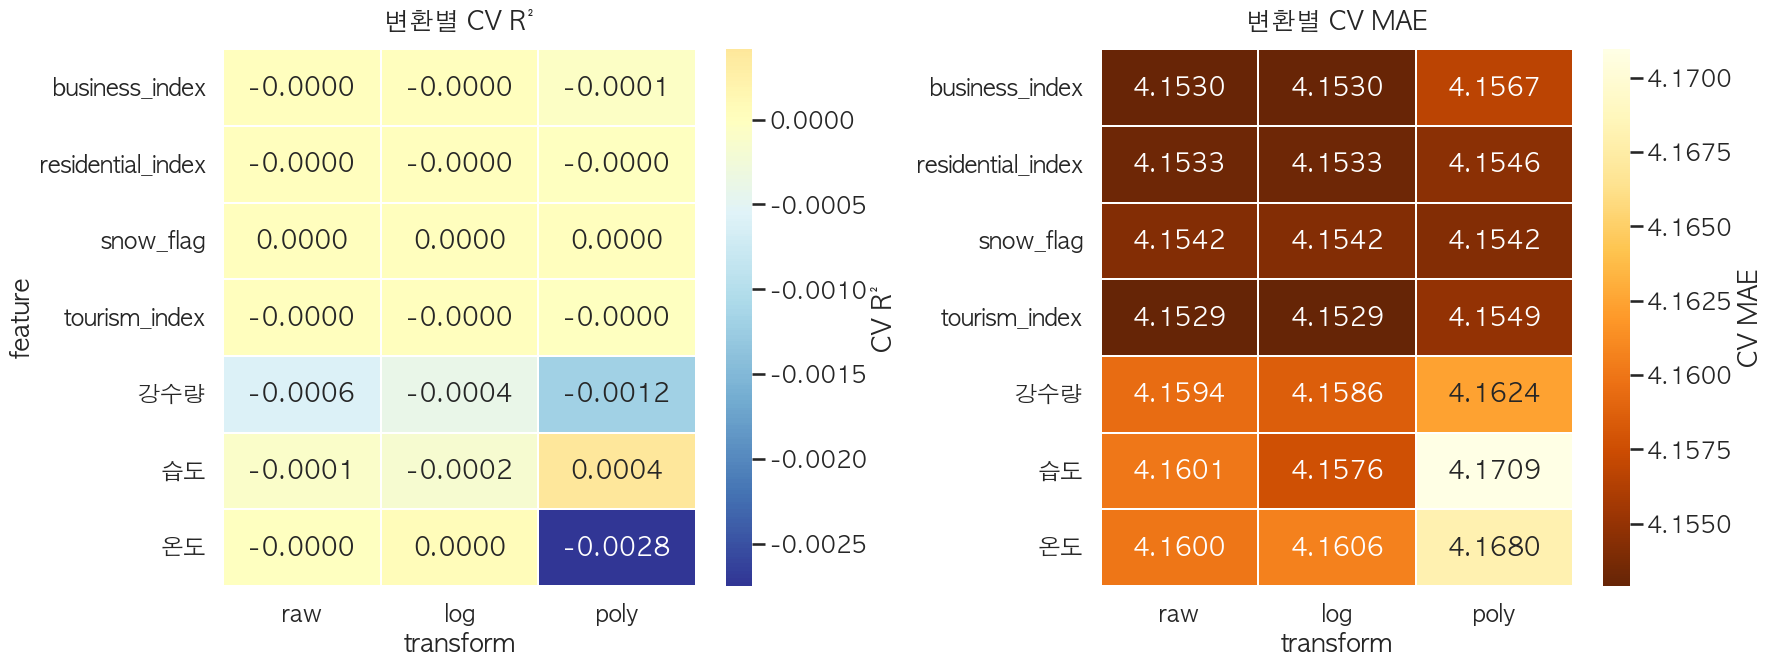

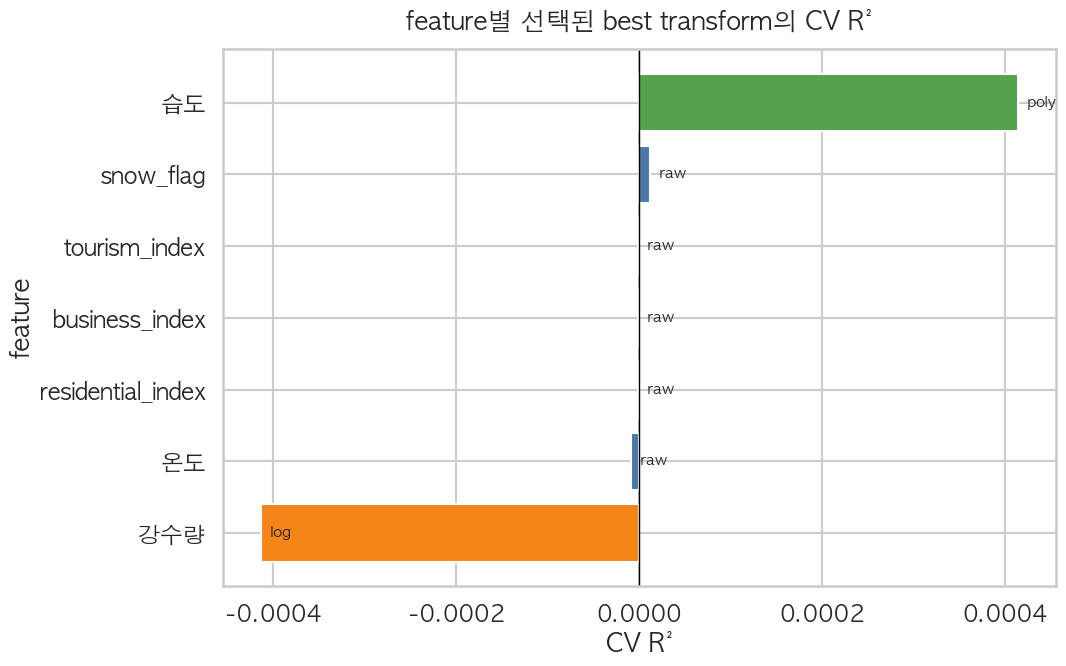

In [64]:
r2_pivot = score_df.pivot(index="feature", columns="transform", values="cv_r2_mean").reindex(columns=TRANSFORM_ORDER)
mae_pivot = score_df.pivot(index="feature", columns="transform", values="cv_mae_mean").reindex(columns=TRANSFORM_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    r2_pivot,
    annot=True,
    fmt=".4f",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.3,
    cbar_kws={"label": "CV R²"},
    ax=axes[0],
)
axes[0].set_title("변환별 CV R²", pad=14)
axes[0].set_xlabel("transform")
axes[0].set_ylabel("feature")

sns.heatmap(
    mae_pivot,
    annot=True,
    fmt=".4f",
    cmap="YlOrBr_r",
    linewidths=0.3,
    cbar_kws={"label": "CV MAE"},
    ax=axes[1],
)
axes[1].set_title("변환별 CV MAE", pad=14)
axes[1].set_xlabel("transform")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

plot_best = best_transform_df.sort_values("cv_r2_mean").copy()
color_map = {"raw": "#4C78A8", "log": "#F58518", "poly": "#54A24B"}
bar_colors = plot_best["transform"].map(color_map)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_best["feature"], plot_best["cv_r2_mean"], color=bar_colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("feature별 선택된 best transform의 CV R²", pad=14)
ax.set_xlabel("CV R²")
ax.set_ylabel("feature")

for idx, row in plot_best.reset_index(drop=True).iterrows():
    ax.text(
        row["cv_r2_mean"],
        idx,
        f"  {row['transform']}",
        va="center",
        ha="left",
        fontsize=11,
    )

plt.tight_layout()
plt.show()


## 5. feature별 상세 시각화

각 feature마다 동일한 x축(원본 feature 값) 위에서 `raw` / `log` / `poly` 적합선을 비교합니다.

- 파란 점: 원 데이터
- 검은 점선: 구간 평균
- 빨간 선: 해당 transform의 단순 회귀 적합선


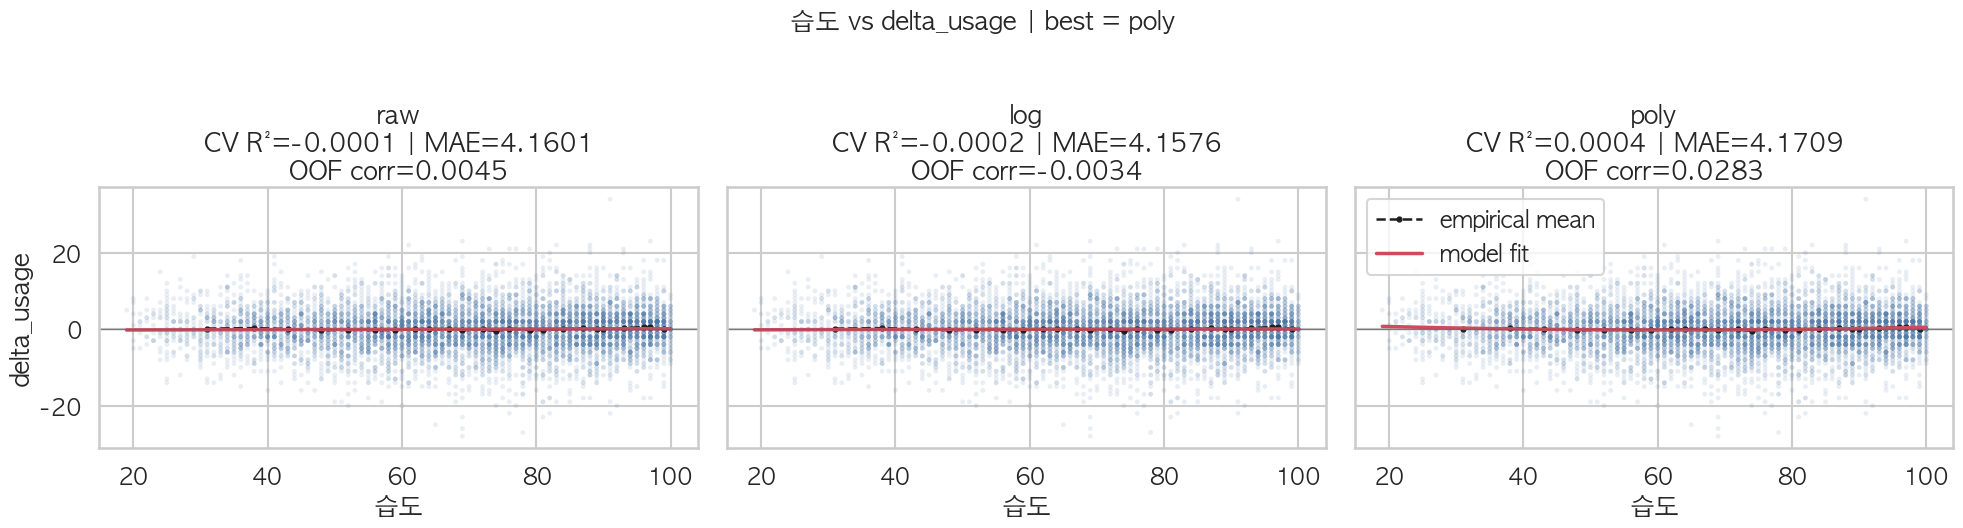

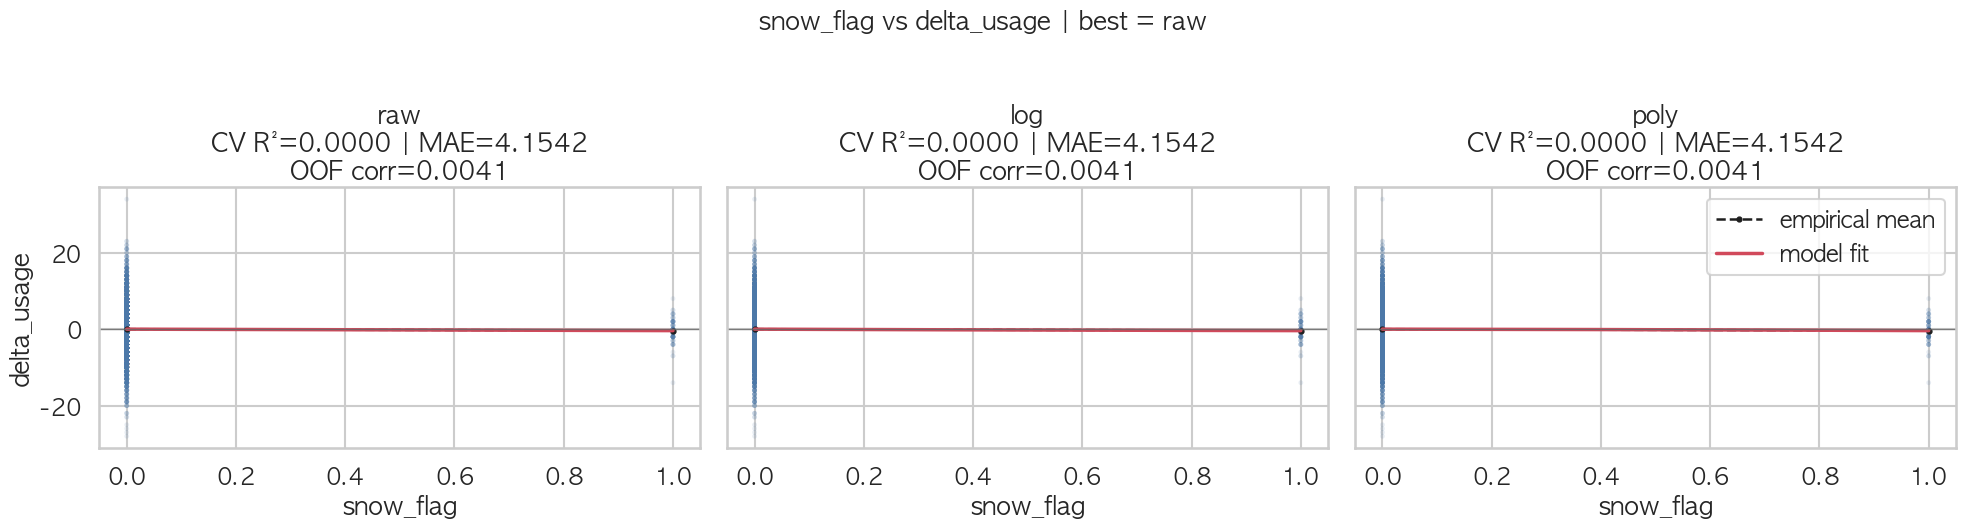

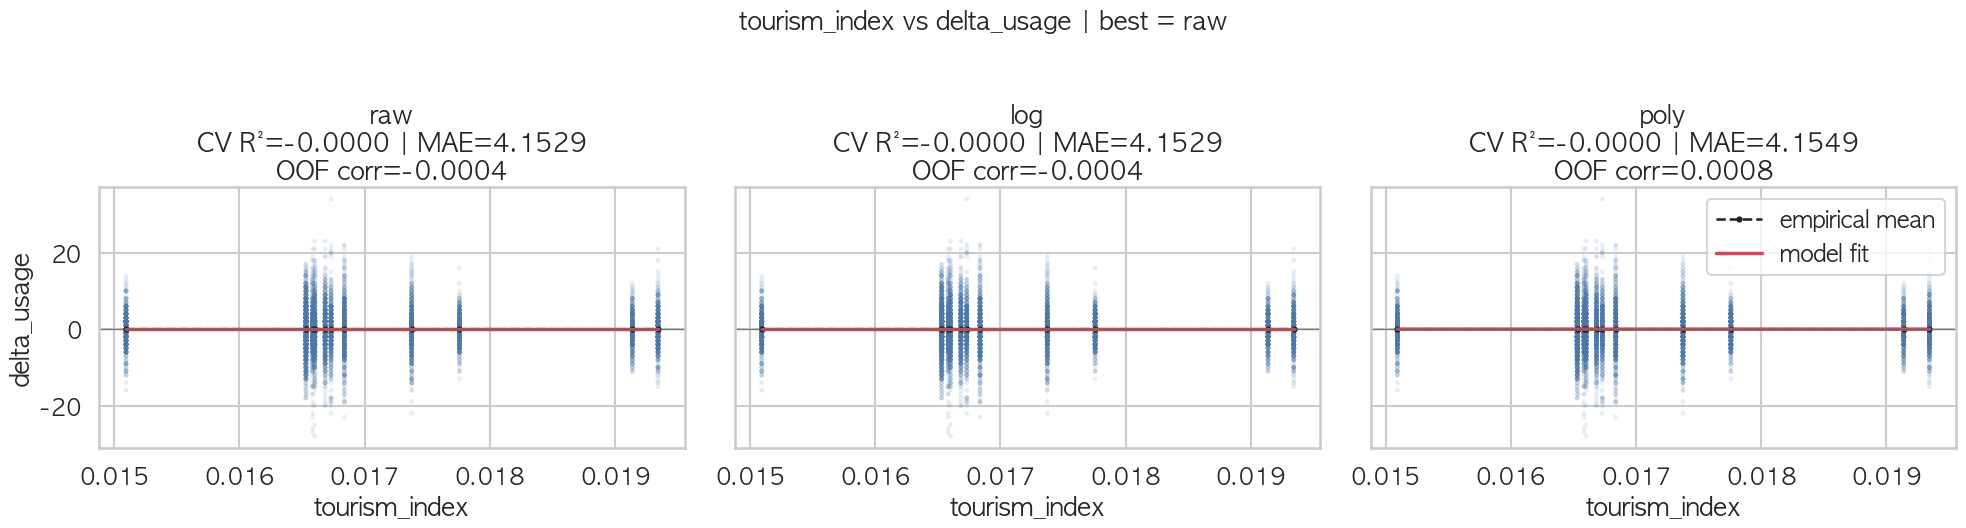

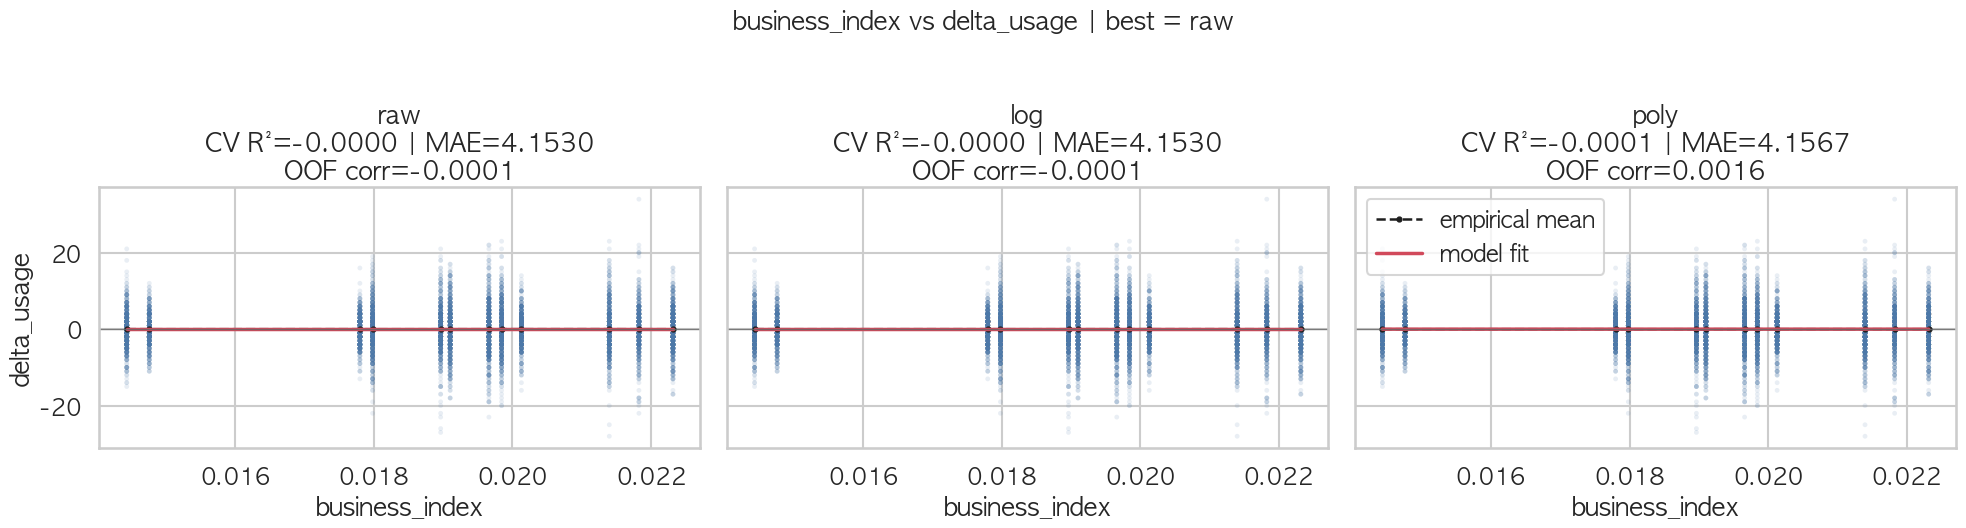

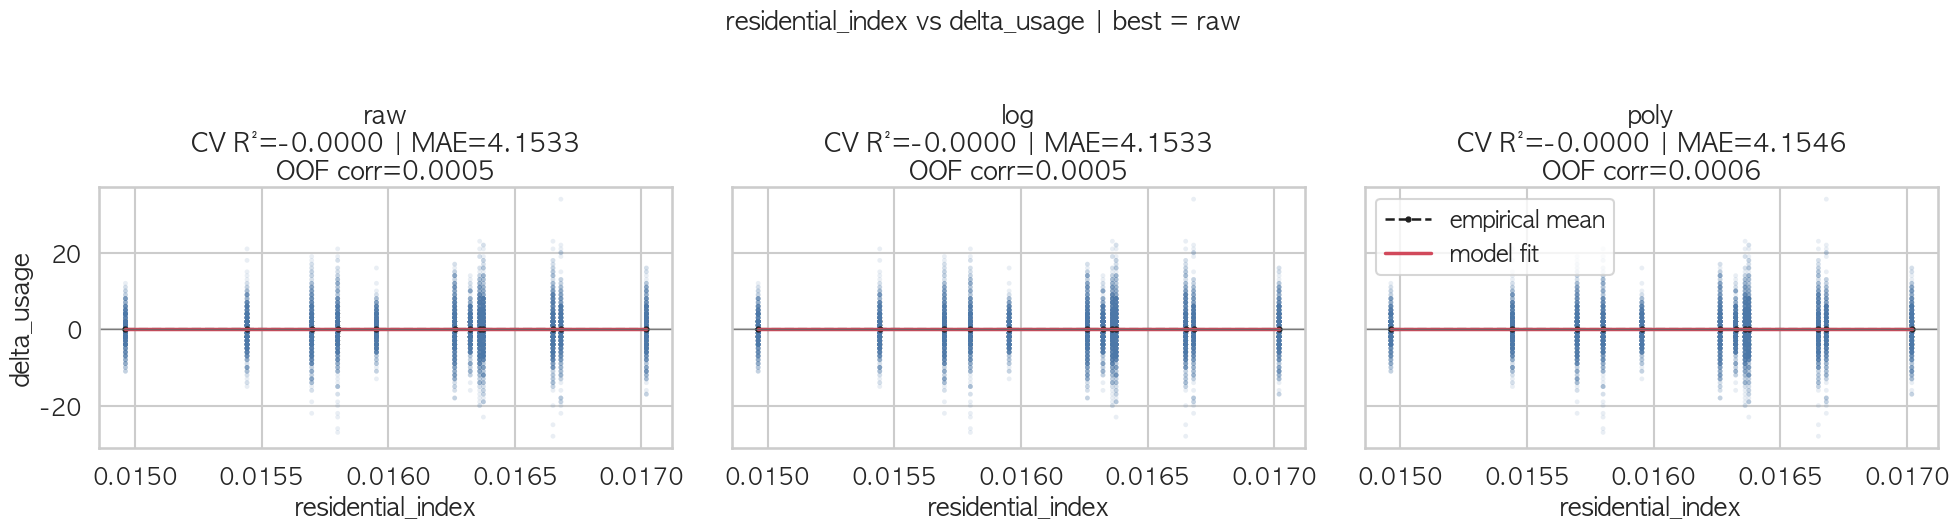

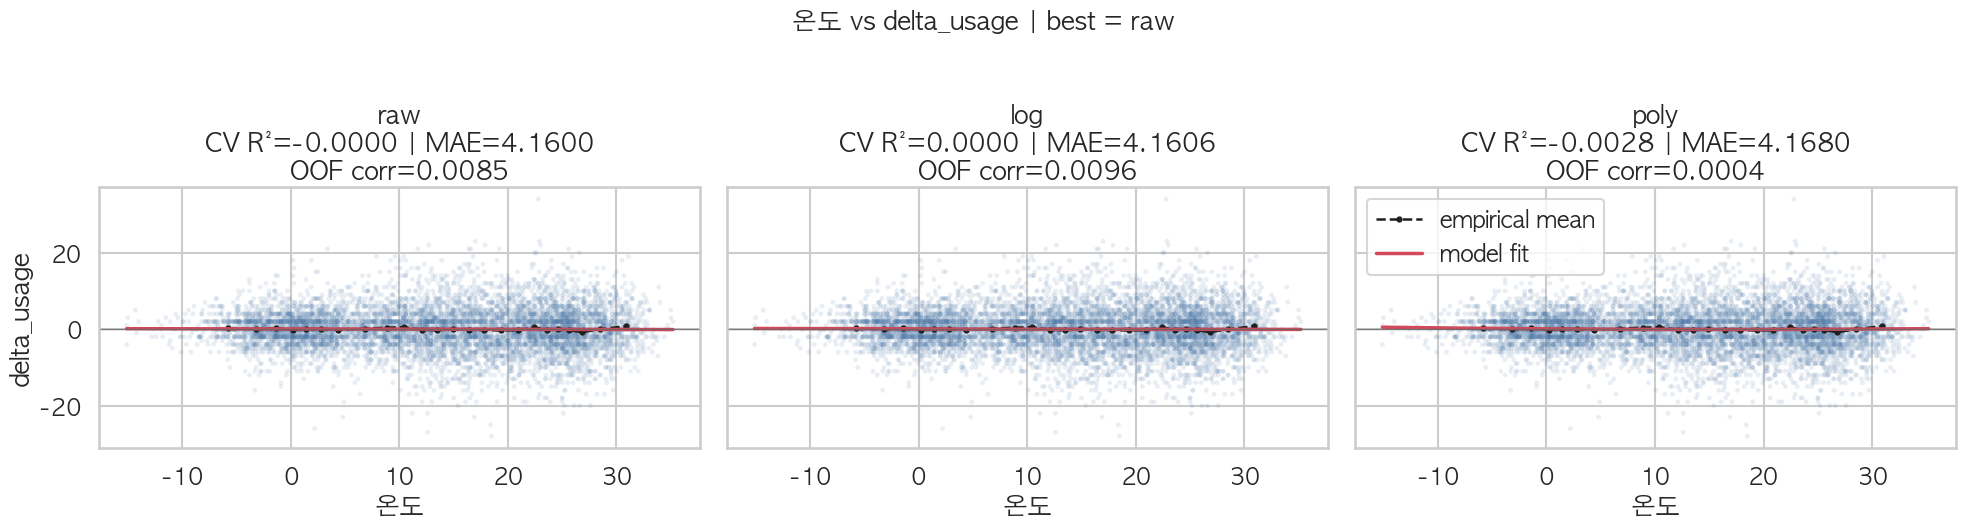

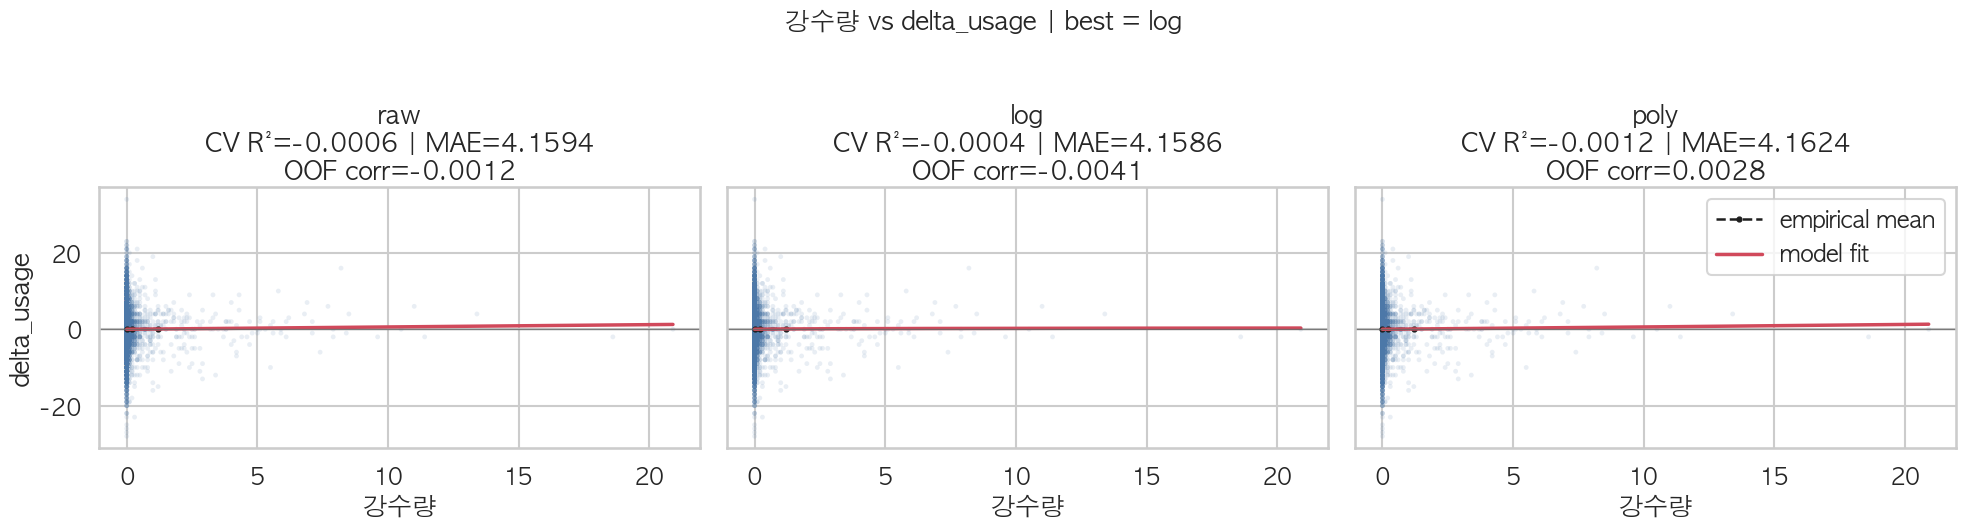

In [65]:
feature_plot_order = best_transform_df["feature"].tolist()

for feature in feature_plot_order:
    plot_feature_transform_comparison(
        frame=df,
        feature=feature,
        target_col=TARGET_COL,
        score_frame=score_df,
    )


## 6. 선택된 변환 적용과 원본 feature 처리

feature별 best transform을 먼저 구하되, raw 대비 유리할 때만 변환을 적용합니다. 변환이 적용된 feature만 원본을 제거하고, 그렇지 않으면 원본을 유지합니다.

- `raw` -> `<feature>__raw`
- `log` -> `<feature>__log`
- `poly` -> `<feature>__poly_1`, `<feature>__poly_2`


In [66]:
transformed_feature_frames = []
transform_spec_rows = []
dropped_original_features = []
kept_original_features = []

for row in best_transform_df.sort_values("feature").itertuples(index=False):
    feature = row.feature
    best_transform = row.transform
    applied_transform = row.applied_transform
    source_series = df[feature].astype(float)

    if applied_transform == "raw":
        kept_original_features.append(feature)
        transform_spec_rows.append(
            {
                "source_feature": feature,
                "best_transform": best_transform,
                "applied_transform": applied_transform,
                "action": "keep_original",
                "created_columns": "",
            }
        )
        continue

    if applied_transform == "log":
        created = pd.DataFrame({f"{feature}__log": signed_log1p(source_series)}, index=df.index)
    elif applied_transform == "poly":
        created = pd.DataFrame(
            {
                f"{feature}__poly_1": source_series,
                f"{feature}__poly_2": np.square(source_series),
            },
            index=df.index,
        )
    else:
        raise ValueError(f"지원하지 않는 transform: {applied_transform}")

    transformed_feature_frames.append(created)
    dropped_original_features.append(feature)
    transform_spec_rows.append(
        {
            "source_feature": feature,
            "best_transform": best_transform,
            "applied_transform": applied_transform,
            "action": "replace_with_transformed",
            "created_columns": ", ".join(created.columns.tolist()),
        }
    )

transform_spec_df = pd.DataFrame(transform_spec_rows).sort_values("source_feature").reset_index(drop=True)
if transformed_feature_frames:
    transformed_feature_df = pd.concat(transformed_feature_frames, axis=1)
else:
    transformed_feature_df = pd.DataFrame(index=df.index)

model_ready_df = pd.concat(
    [df.drop(columns=dropped_original_features), transformed_feature_df],
    axis=1,
)

print(f"원본 데이터 shape: {df.shape}")
print(f"변환 후 데이터 shape: {model_ready_df.shape}")
print(f"원본 유지 feature 수: {len(kept_original_features)}")
print(f"삭제한 원본 feature 수: {len(dropped_original_features)}")
print(f"생성한 변환 feature 수: {transformed_feature_df.shape[1]}")

display(transform_spec_df)
display(model_ready_df.head())

model_ready_df.columns.tolist()


원본 데이터 shape: (7753, 35)
변환 후 데이터 shape: (7753, 36)
원본 유지 feature 수: 5
삭제한 원본 feature 수: 2
생성한 변환 feature 수: 3


,source_feature,best_transform,applied_transform,action,created_columns
0,business_index,raw,raw,keep_original,
1,residential_index,raw,raw,keep_original,
2,snow_flag,raw,raw,keep_original,
3,tourism_index,raw,raw,keep_original,
4,강수량,log,log,replace_with_transformed,강수량__log
5,습도,poly,poly,replace_with_transformed,"습도__poly_1, 습도__poly_2"
6,온도,raw,raw,keep_original,


,기준_날짜,시간대,온도,timestamp,station_id,위도,경도,station_dong,year,month_sin,...,tourism_index,transit_index,commute_in_index,commute_out_index,snow_flag,usage,delta_usage,강수량__log,습도__poly_1,습도__poly_2
0,2024-01-01,0,-2.7000,2024-01-01 00:00:00,ST-1331,37.5944,126.9180,NaN,2024,0.0000,...,0.0178,0.0000,0.0000,0.0000,0,0,0,0.0000,92.0000,"8,464.0000"
1,2024-01-01,2,-1.2000,2024-01-01 02:00:00,ST-1331,37.5944,126.9180,NaN,2024,0.0000,...,0.0178,0.0000,0.0000,0.0000,0,2,2,0.0000,88.0000,"7,744.0000"
2,2024-01-01,4,-1.0000,2024-01-01 04:00:00,ST-1331,37.5944,126.9180,NaN,2024,0.0000,...,0.0178,0.0000,0.0000,0.0000,0,4,2,0.0000,87.0000,"7,569.0000"
3,2024-01-01,5,-1.0000,2024-01-01 05:00:00,ST-1331,37.5944,126.9180,NaN,2024,0.0000,...,0.0178,0.0000,0.0000,0.0000,0,2,-2,0.0000,87.0000,"7,569.0000"
4,2024-01-01,6,-0.9000,2024-01-01 06:00:00,ST-1331,37.5944,126.9180,NaN,2024,0.0000,...,0.0178,0.0000,0.0000,0.0000,0,2,0,0.0000,88.0000,"7,744.0000"


['기준_날짜',
 '시간대',
 '온도',
 'timestamp',
 'station_id',
 '위도',
 '경도',
 'station_dong',
 'year',
 'month_sin',
 'month_cos',
 'is_restingday',
 'weekday_0',
 'weekday_1',
 'weekday_2',
 'weekday_3',
 'weekday_4',
 'weekday_5',
 'weekday_6',
 'hour_sin',
 'hour_cos',
 'is_noon',
 'is_rushhour',
 'month',
 'residential_index',
 'business_index',
 'tourism_index',
 'transit_index',
 'commute_in_index',
 'commute_out_index',
 'snow_flag',
 'usage',
 'delta_usage',
 '강수량__log',
 '습도__poly_1',
 '습도__poly_2']

## 7. Feature Selection 비교

`model_ready_df`를 기준으로 `SelectKBest`, `SelectFromModel`, `RFECV`를 동일한 시계열 분할 규칙으로 비교합니다.

- 비교 입력: info 컬럼, 시간 관련 feature, `usage`, 타깃(`delta_usage`)을 제외한 수치형 feature
- 평가 모델: `Ridge`
- outer split: holdout 성능 비교
- inner split: selector 내부 튜닝


In [67]:
from sklearn.feature_selection import RFECV, SelectFromModel, SelectKBest, f_regression
from sklearn.linear_model import Ridge

SELECTION_OUTER_SPLITS = 4
SELECTION_INNER_SPLITS = 3
SELECTION_METHODS = ["SelectKBest", "SelectFromModel", "RFECV"]
RIDGE_ALPHA = 1.0

selection_exclude_cols = EXCLUDE_COLS | {TARGET_COL}
selection_feature_cols = [
    col
    for col in model_ready_df.columns
    if col not in selection_exclude_cols
    and pd.api.types.is_numeric_dtype(model_ready_df[col])
    and model_ready_df[col].nunique(dropna=True) > 1
]

selection_df = model_ready_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)
X_selection = selection_df[selection_feature_cols].astype(float)
y_selection = selection_df[TARGET_COL].astype(float)

print(f"feature selection 입력 shape: {X_selection.shape}")
print(f"feature 수: {len(selection_feature_cols)}")
display(pd.DataFrame({"feature": selection_feature_cols}))


def make_ridge_estimator():
    return Ridge(alpha=RIDGE_ALPHA)


def scale_train_test(X_train_df, X_test_df):
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_df),
        columns=X_train_df.columns,
        index=X_train_df.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_df),
        columns=X_test_df.columns,
        index=X_test_df.index,
    )
    return X_train_scaled, X_test_scaled


def choose_best_candidate(candidate_df):
    ranked = candidate_df.copy()
    ranked["cv_r2_round"] = ranked["cv_r2_mean"].round(4)
    ranked["cv_mae_round"] = ranked["cv_mae_mean"].round(4)
    ranked["oof_corr_abs_round"] = ranked["oof_corr"].abs().round(4)
    ranked = ranked.sort_values(
        ["cv_r2_round", "cv_mae_round", "oof_corr_abs_round", "n_selected"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)
    return ranked.iloc[0], ranked


def evaluate_selector_candidate(selector_builder, X_df, y, inner_splits, param_value):
    splitter = TimeSeriesSplit(n_splits=inner_splits)
    oof_pred = pd.Series(np.nan, index=X_df.index, dtype=float)
    fold_r2 = []
    fold_mae = []
    selected_counts = []

    for train_idx, valid_idx in splitter.split(X_df):
        selector = selector_builder()
        X_train = X_df.iloc[train_idx]
        X_valid = X_df.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        selector.fit(X_train, y_train)
        support_mask = selector.get_support()
        selected_cols = X_df.columns[support_mask].tolist()
        if not selected_cols:
            raise ValueError("선택된 feature가 없습니다.")

        model = make_ridge_estimator()
        model.fit(X_train[selected_cols], y_train)
        pred = model.predict(X_valid[selected_cols])

        oof_pred.iloc[valid_idx] = pred
        fold_r2.append(r2_score(y_valid, pred))
        fold_mae.append(mean_absolute_error(y_valid, pred))
        selected_counts.append(len(selected_cols))

    valid_mask = oof_pred.notna()
    return {
        "param_value": param_value,
        "n_selected": int(np.median(selected_counts)),
        "cv_r2_mean": float(np.mean(fold_r2)),
        "cv_mae_mean": float(np.mean(fold_mae)),
        "oof_corr": float(pd.Series(oof_pred[valid_mask]).corr(y[valid_mask])),
    }


def tune_select_k_best(X_train_scaled, y_train, inner_splits):
    candidate_rows = []
    for k in range(1, X_train_scaled.shape[1] + 1):
        candidate_rows.append(
            evaluate_selector_candidate(
                selector_builder=lambda k=k: SelectKBest(score_func=f_regression, k=k),
                X_df=X_train_scaled,
                y=y_train,
                inner_splits=inner_splits,
                param_value=k,
            )
        )

    best_row, tuning_df = choose_best_candidate(pd.DataFrame(candidate_rows))
    selector = SelectKBest(score_func=f_regression, k=int(best_row["param_value"]))
    selector.fit(X_train_scaled, y_train)
    selected_cols = X_train_scaled.columns[selector.get_support()].tolist()
    return {
        "method": "SelectKBest",
        "selector": selector,
        "selected_features": selected_cols,
        "selected_count": len(selected_cols),
        "best_param": int(best_row["param_value"]),
        "tuning_df": tuning_df.assign(method="SelectKBest", x_value=tuning_df["param_value"]),
    }


def tune_select_from_model(X_train_scaled, y_train, inner_splits):
    candidate_rows = []
    for k in range(1, X_train_scaled.shape[1] + 1):
        candidate_rows.append(
            evaluate_selector_candidate(
                selector_builder=lambda k=k: SelectFromModel(
                    estimator=Ridge(alpha=RIDGE_ALPHA),
                    threshold=-np.inf,
                    max_features=k,
                ),
                X_df=X_train_scaled,
                y=y_train,
                inner_splits=inner_splits,
                param_value=k,
            )
        )

    best_row, tuning_df = choose_best_candidate(pd.DataFrame(candidate_rows))
    selector = SelectFromModel(
        estimator=Ridge(alpha=RIDGE_ALPHA),
        threshold=-np.inf,
        max_features=int(best_row["param_value"]),
    )
    selector.fit(X_train_scaled, y_train)
    selected_cols = X_train_scaled.columns[selector.get_support()].tolist()
    return {
        "method": "SelectFromModel",
        "selector": selector,
        "selected_features": selected_cols,
        "selected_count": len(selected_cols),
        "best_param": int(best_row["param_value"]),
        "tuning_df": tuning_df.assign(method="SelectFromModel", x_value=tuning_df["param_value"]),
    }


def tune_rfecv(X_train_scaled, y_train, inner_splits):
    selector = RFECV(
        estimator=Ridge(alpha=RIDGE_ALPHA),
        step=1,
        min_features_to_select=1,
        cv=TimeSeriesSplit(n_splits=inner_splits),
        scoring="r2",
    )
    selector.fit(X_train_scaled, y_train)
    selected_cols = X_train_scaled.columns[selector.support_].tolist()

    if hasattr(selector, "cv_results_"):
        cv_results = selector.cv_results_
        mean_test_score = np.asarray(cv_results.get("mean_test_score", []), dtype=float).reshape(-1)
        if "n_features" in cv_results:
            n_features = np.asarray(cv_results["n_features"]).reshape(-1)
        else:
            n_features = np.arange(1, len(mean_test_score) + 1)
    else:
        mean_test_score = np.asarray(selector.grid_scores_, dtype=float).reshape(-1)
        n_features = np.arange(1, len(mean_test_score) + 1)

    tuning_df = pd.DataFrame(
        {
            "n_features": n_features,
            "cv_r2_mean": mean_test_score,
        }
    )
    tuning_df["method"] = "RFECV"
    tuning_df["x_value"] = tuning_df["n_features"]

    return {
        "method": "RFECV",
        "selector": selector,
        "selected_features": selected_cols,
        "selected_count": len(selected_cols),
        "best_param": len(selected_cols),
        "tuning_df": tuning_df,
    }


def fit_selection_method(method_name, X_train_scaled, y_train, inner_splits):
    if method_name == "SelectKBest":
        return tune_select_k_best(X_train_scaled, y_train, inner_splits)
    if method_name == "SelectFromModel":
        return tune_select_from_model(X_train_scaled, y_train, inner_splits)
    if method_name == "RFECV":
        return tune_rfecv(X_train_scaled, y_train, inner_splits)
    raise ValueError(f"지원하지 않는 method: {method_name}")


def run_outer_comparison(X_df, y, methods, outer_splits, inner_splits):
    outer_rows = []
    outer_feature_rows = []
    outer_splitter = TimeSeriesSplit(n_splits=outer_splits)

    for method_name in methods:
        for fold_idx, (train_idx, test_idx) in enumerate(outer_splitter.split(X_df), start=1):
            X_train_df = X_df.iloc[train_idx]
            X_test_df = X_df.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            X_train_scaled, X_test_scaled = scale_train_test(X_train_df, X_test_df)
            fit_result = fit_selection_method(method_name, X_train_scaled, y_train, inner_splits)
            selected_cols = fit_result["selected_features"]

            model = make_ridge_estimator()
            model.fit(X_train_scaled[selected_cols], y_train)
            pred = model.predict(X_test_scaled[selected_cols])

            outer_rows.append(
                {
                    "method": method_name,
                    "fold": fold_idx,
                    "selected_count": len(selected_cols),
                    "best_param": fit_result["best_param"],
                    "test_r2": float(r2_score(y_test, pred)),
                    "test_mae": float(mean_absolute_error(y_test, pred)),
                }
            )

            for feature in selected_cols:
                outer_feature_rows.append(
                    {
                        "method": method_name,
                        "fold": fold_idx,
                        "feature": feature,
                    }
                )

    return pd.DataFrame(outer_rows), pd.DataFrame(outer_feature_rows)


outer_compare_df, outer_selected_feature_df = run_outer_comparison(
    X_df=X_selection,
    y=y_selection,
    methods=SELECTION_METHODS,
    outer_splits=SELECTION_OUTER_SPLITS,
    inner_splits=SELECTION_INNER_SPLITS,
)

selection_summary_df = (
    outer_compare_df.groupby("method", as_index=False)
    .agg(
        test_r2_mean=("test_r2", "mean"),
        test_r2_std=("test_r2", "std"),
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        selected_count_mean=("selected_count", "mean"),
    )
    .sort_values(["test_r2_mean", "test_mae_mean"], ascending=[False, True])
    .reset_index(drop=True)
)

X_selection_scaled_full = pd.DataFrame(
    StandardScaler().fit_transform(X_selection),
    columns=X_selection.columns,
    index=X_selection.index,
)

full_fit_results = {}
full_tuning_frames = []
full_selected_rows = []
for method_name in SELECTION_METHODS:
    fit_result = fit_selection_method(method_name, X_selection_scaled_full, y_selection, SELECTION_INNER_SPLITS)
    full_fit_results[method_name] = fit_result
    full_tuning_frames.append(fit_result["tuning_df"])
    full_selected_rows.append(
        {
            "method": method_name,
            "selected_count": fit_result["selected_count"],
            "best_param": fit_result["best_param"],
            "selected_features": ", ".join(fit_result["selected_features"]),
        }
    )

full_tuning_df = pd.concat(full_tuning_frames, ignore_index=True)
full_selected_summary_df = pd.DataFrame(full_selected_rows)

selection_matrix = pd.DataFrame(0, index=selection_feature_cols, columns=SELECTION_METHODS)
for method_name, fit_result in full_fit_results.items():
    selection_matrix.loc[fit_result["selected_features"], method_name] = 1

best_selection_method = selection_summary_df.iloc[0]["method"]
best_selection_features = full_fit_results[best_selection_method]["selected_features"]

display(selection_summary_df)
display(full_selected_summary_df)
print(f"best selection method: {best_selection_method}")
print(f"selected features ({len(best_selection_features)}개): {best_selection_features}")


feature selection 입력 shape: (7753, 8)
feature 수: 8


,feature
0,온도
1,residential_index
2,business_index
3,tourism_index
4,snow_flag
5,강수량__log
6,습도__poly_1
7,습도__poly_2


,method,test_r2_mean,test_r2_std,test_mae_mean,test_mae_std,selected_count_mean
0,SelectFromModel,0.0015,0.0008,4.2085,0.3490,3.5000
1,RFECV,0.0014,0.0008,4.2100,0.3464,2.7500
2,SelectKBest,0.0005,0.0012,4.2134,0.3506,5.5000


,method,selected_count,best_param,selected_features
0,SelectKBest,5,5,"온도, snow_flag, 강수량__log, 습도__poly_1, 습도__poly_2"
1,SelectFromModel,4,4,"온도, snow_flag, 습도__poly_1, 습도__poly_2"
2,RFECV,2,2,"습도__poly_1, 습도__poly_2"


best selection method: SelectFromModel
selected features (4개): ['온도', 'snow_flag', '습도__poly_1', '습도__poly_2']


## 8. Feature Selection 시각화

세 방법의 성능 비교, tuning curve, 최종 선택 feature heatmap을 확인합니다.


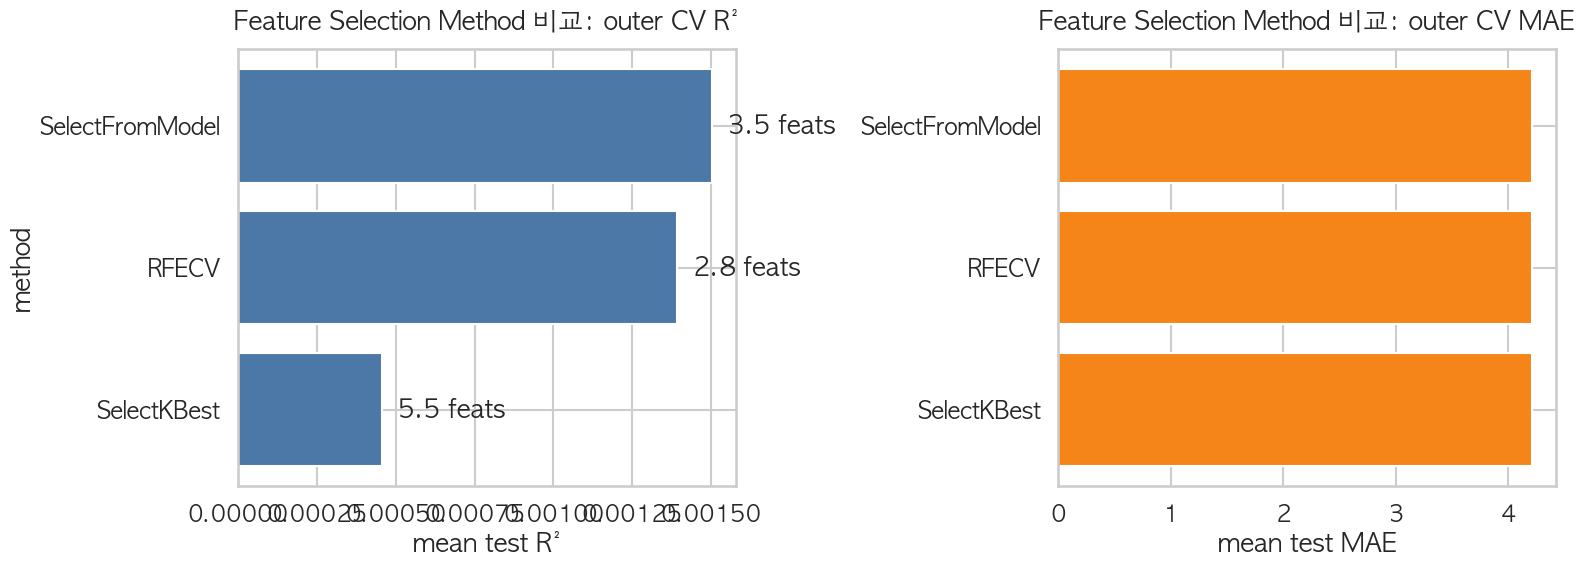

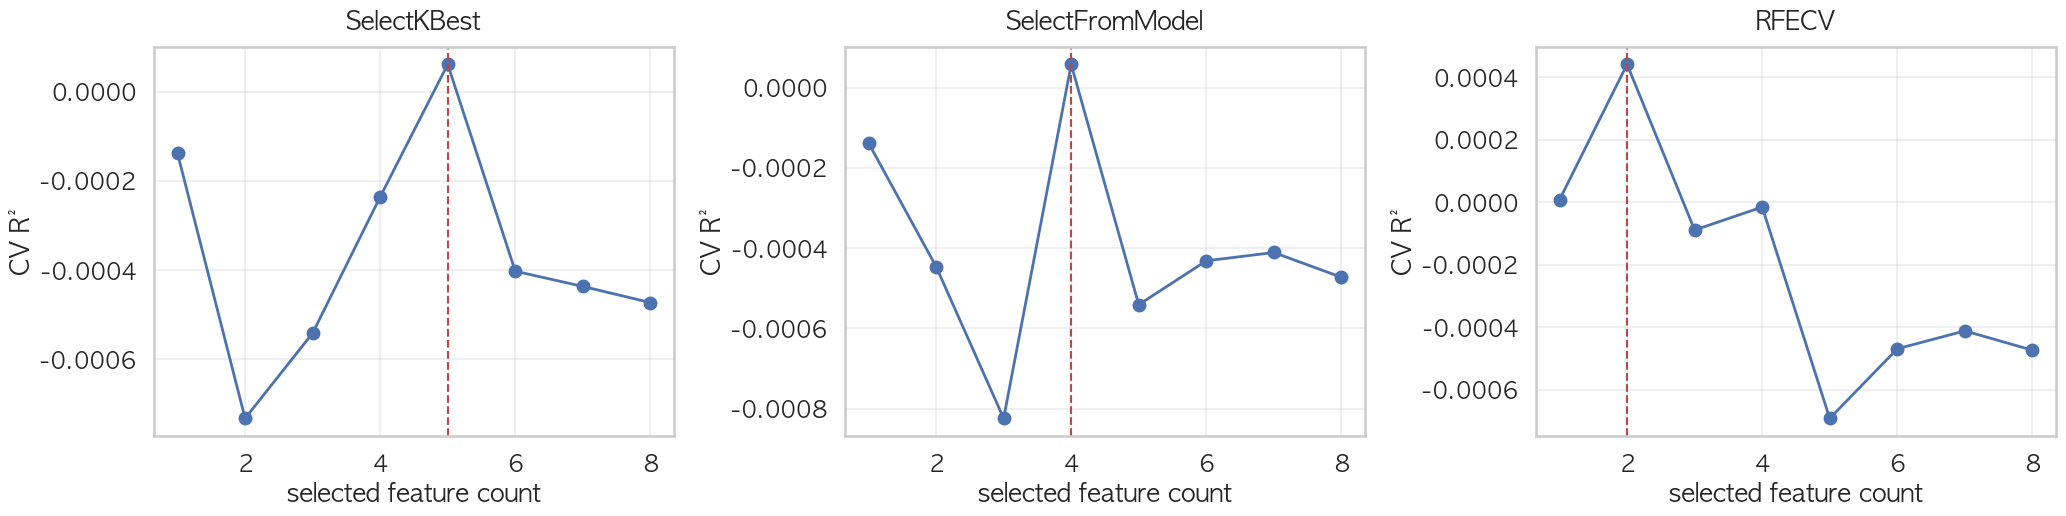

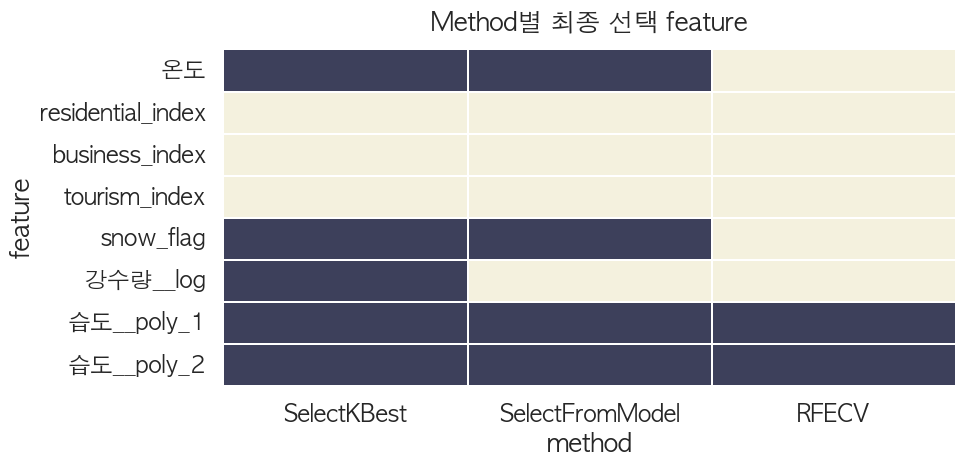

,method,feature,selected_in_outer_folds
3,RFECV,습도__poly_1,4
4,RFECV,습도__poly_2,4
0,RFECV,business_index,1
1,RFECV,tourism_index,1
2,RFECV,강수량__log,1
8,SelectFromModel,습도__poly_1,4
9,SelectFromModel,습도__poly_2,4
6,SelectFromModel,tourism_index,2
10,SelectFromModel,온도,2
5,SelectFromModel,business_index,1


In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_r2 = selection_summary_df.sort_values("test_r2_mean", ascending=True)
summary_mae = selection_summary_df.sort_values("test_mae_mean", ascending=False)

axes[0].barh(summary_r2["method"], summary_r2["test_r2_mean"], color="#4C78A8")
axes[0].set_title("Feature Selection Method 비교: outer CV R²", pad=14)
axes[0].set_xlabel("mean test R²")
axes[0].set_ylabel("method")
for idx, row in summary_r2.reset_index(drop=True).iterrows():
    axes[0].text(row["test_r2_mean"], idx, f"  {row['selected_count_mean']:.1f} feats", va="center")

axes[1].barh(summary_mae["method"], summary_mae["test_mae_mean"], color="#F58518")
axes[1].set_title("Feature Selection Method 비교: outer CV MAE", pad=14)
axes[1].set_xlabel("mean test MAE")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(21, 5.5), sharey=False)
for ax, method_name in zip(axes, SELECTION_METHODS):
    tuning_plot_df = full_tuning_df.loc[full_tuning_df["method"] == method_name].copy()
    tuning_plot_df = tuning_plot_df.sort_values("x_value")
    ax.plot(tuning_plot_df["x_value"], tuning_plot_df["cv_r2_mean"], marker="o", linewidth=2)
    best_count = full_fit_results[method_name]["selected_count"]
    ax.axvline(best_count, color="#BC4749", linestyle="--", linewidth=1.5)
    ax.set_title(method_name, pad=12)
    ax.set_xlabel("selected feature count")
    ax.set_ylabel("CV R²")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(selection_matrix))))
sns.heatmap(
    selection_matrix,
    cmap=sns.color_palette(["#F4F1DE", "#3D405B"], as_cmap=True),
    cbar=False,
    linewidths=0.3,
    linecolor="white",
    ax=ax,
)
ax.set_title("Method별 최종 선택 feature", pad=14)
ax.set_xlabel("method")
ax.set_ylabel("feature")
plt.tight_layout()
plt.show()

selection_frequency_df = (
    outer_selected_feature_df.groupby(["method", "feature"]).size().rename("selected_in_outer_folds").reset_index()
)
display(selection_frequency_df.sort_values(["method", "selected_in_outer_folds", "feature"], ascending=[True, False, True]))


## 9. 최고 점수 방법 선택

비교 결과에서 최고 점수 방법 하나를 고르고, 그 방법이 선택한 최종 feature만 남깁니다.


In [69]:
best_selection_method = (
    selection_summary_df.sort_values(
        ["test_r2_mean", "test_mae_mean", "selected_count_mean"],
        ascending=[False, True, True],
    )
    .iloc[0]["method"]
)

best_selection_features = full_fit_results[best_selection_method]["selected_features"]

selected_feature_df = selection_df[best_selection_features + [TARGET_COL]].copy()
selected_feature_summary_df = pd.DataFrame({"feature": best_selection_features})

print(best_selection_method)
display(selected_feature_summary_df)
display(selected_feature_df.head())


SelectFromModel


,feature
0,온도
1,snow_flag
2,습도__poly_1
3,습도__poly_2


,온도,snow_flag,습도__poly_1,습도__poly_2,delta_usage
0,-2.7000,0,92.0000,"8,464.0000",0
1,-1.2000,0,88.0000,"7,744.0000",2
2,-1.0000,0,87.0000,"7,569.0000",2
3,-1.0000,0,87.0000,"7,569.0000",-2
4,-0.9000,0,88.0000,"7,744.0000",0


## 10. 시간 + 선택 feature + 타깃 저장

`기준_날짜`, `timestamp`는 제거하고 `year`를 포함한 시간 관련 컬럼과 최종 선택 feature, 타깃만 남겨 `resti_dataset_pre_2.csv`로 저장합니다.


In [70]:
OUTPUT_PRE2_PATH = PROJECT_ROOT / "Data" / "Restitutor" / "resti_dataset_pre_2.csv"

TIME_KEEP_COLS = [
    col
    for col in [
        "year",
        "month",
        "시간대",
        "month_sin",
        "month_cos",
        "is_restingday",
        "weekday_0",
        "weekday_1",
        "weekday_2",
        "weekday_3",
        "weekday_4",
        "weekday_5",
        "weekday_6",
        "hour_sin",
        "hour_cos",
        "is_noon",
        "is_rushhour",
    ]
    if col in selection_df.columns
]

final_pre2_cols = []
for col in TIME_KEEP_COLS + best_selection_features + [TARGET_COL]:
    if col not in final_pre2_cols:
        final_pre2_cols.append(col)

resti_dataset_pre_2_df = selection_df[final_pre2_cols].copy()
OUTPUT_PRE2_PATH.parent.mkdir(parents=True, exist_ok=True)
resti_dataset_pre_2_df.to_csv(OUTPUT_PRE2_PATH, index=False, encoding="utf-8-sig")

print(OUTPUT_PRE2_PATH)
display(pd.DataFrame({"column": final_pre2_cols}))
display(resti_dataset_pre_2_df.head())


/Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/EP_cycle_stations/Data/Restitutor/resti_dataset_pre_2.csv


,column
0,year
1,month
2,시간대
3,month_sin
4,month_cos
5,is_restingday
6,weekday_0
7,weekday_1
8,weekday_2
9,weekday_3


,year,month,시간대,month_sin,month_cos,is_restingday,weekday_0,weekday_1,weekday_2,weekday_3,...,weekday_6,hour_sin,hour_cos,is_noon,is_rushhour,온도,snow_flag,습도__poly_1,습도__poly_2,delta_usage
0,2024,1,0,0.0000,1.0000,1,1,0,0,0,...,0,0.0000,1.0000,0,0,-2.7000,0,92.0000,"8,464.0000",0
1,2024,1,2,0.0000,1.0000,1,1,0,0,0,...,0,0.5000,0.8660,0,0,-1.2000,0,88.0000,"7,744.0000",2
2,2024,1,4,0.0000,1.0000,1,1,0,0,0,...,0,0.8660,0.5000,0,0,-1.0000,0,87.0000,"7,569.0000",2
3,2024,1,5,0.0000,1.0000,1,1,0,0,0,...,0,0.9659,0.2588,0,0,-1.0000,0,87.0000,"7,569.0000",-2
4,2024,1,6,0.0000,1.0000,1,1,0,0,0,...,0,1.0000,0.0000,0,0,-0.9000,0,88.0000,"7,744.0000",0
